# Diagnosing your SBI
Now we've run an SBI fit we need to diagnose that it actually works!

In [1]:
from pathlib import Path

from mach3sbitools.inference import InferenceHandler
from mach3sbitools.simulator import Simulator
from mach3sbitools.utils import MaCh3Logger

MaCh3Logger("mach3sbitools")

/home/henryi/sft/MaCh3SbiTools/.venv/lib/python3.11/site-packages/numba/core/cpu.py:136: UserWarning: Numba extension module 'awkward.numba' failed to load due to 'ModuleNotFoundError(No module named 'importlib_metadata')'.
  numba.core.entrypoints.init_all()


## Directly Comparing Model and SBI Likelihoods
The first and easiest thing we can do is compare the log-likelihood prediction from the SBI and Model likelihoods. We produce 2 plots. One plotting the LLHs against each other in 2D and the other showing the distributions in 1D

In [2]:
# Let's first load the model. This is the same as the CLI `mach3sbi inference` step
prior = Path("prior/my_prior.pkl")
model = Path("models/my_sbi.ckpt")

physics_config = Path("physics_configs/PhysicsConfig.yaml")


# Now we load the simulator
simulator = Simulator(
    "my_simulator",
    "MySimulator",
    physics_config,
)

# Now we grab the inference
inference_handler = InferenceHandler(prior)
inference_handler.load_posterior(model, posterior_config=None)

  0%|          | 0/10000 [00:00<?, ?it/s]

Get LLH from simulator:   0%|          | 0/10000 [00:00<?, ?it/s]

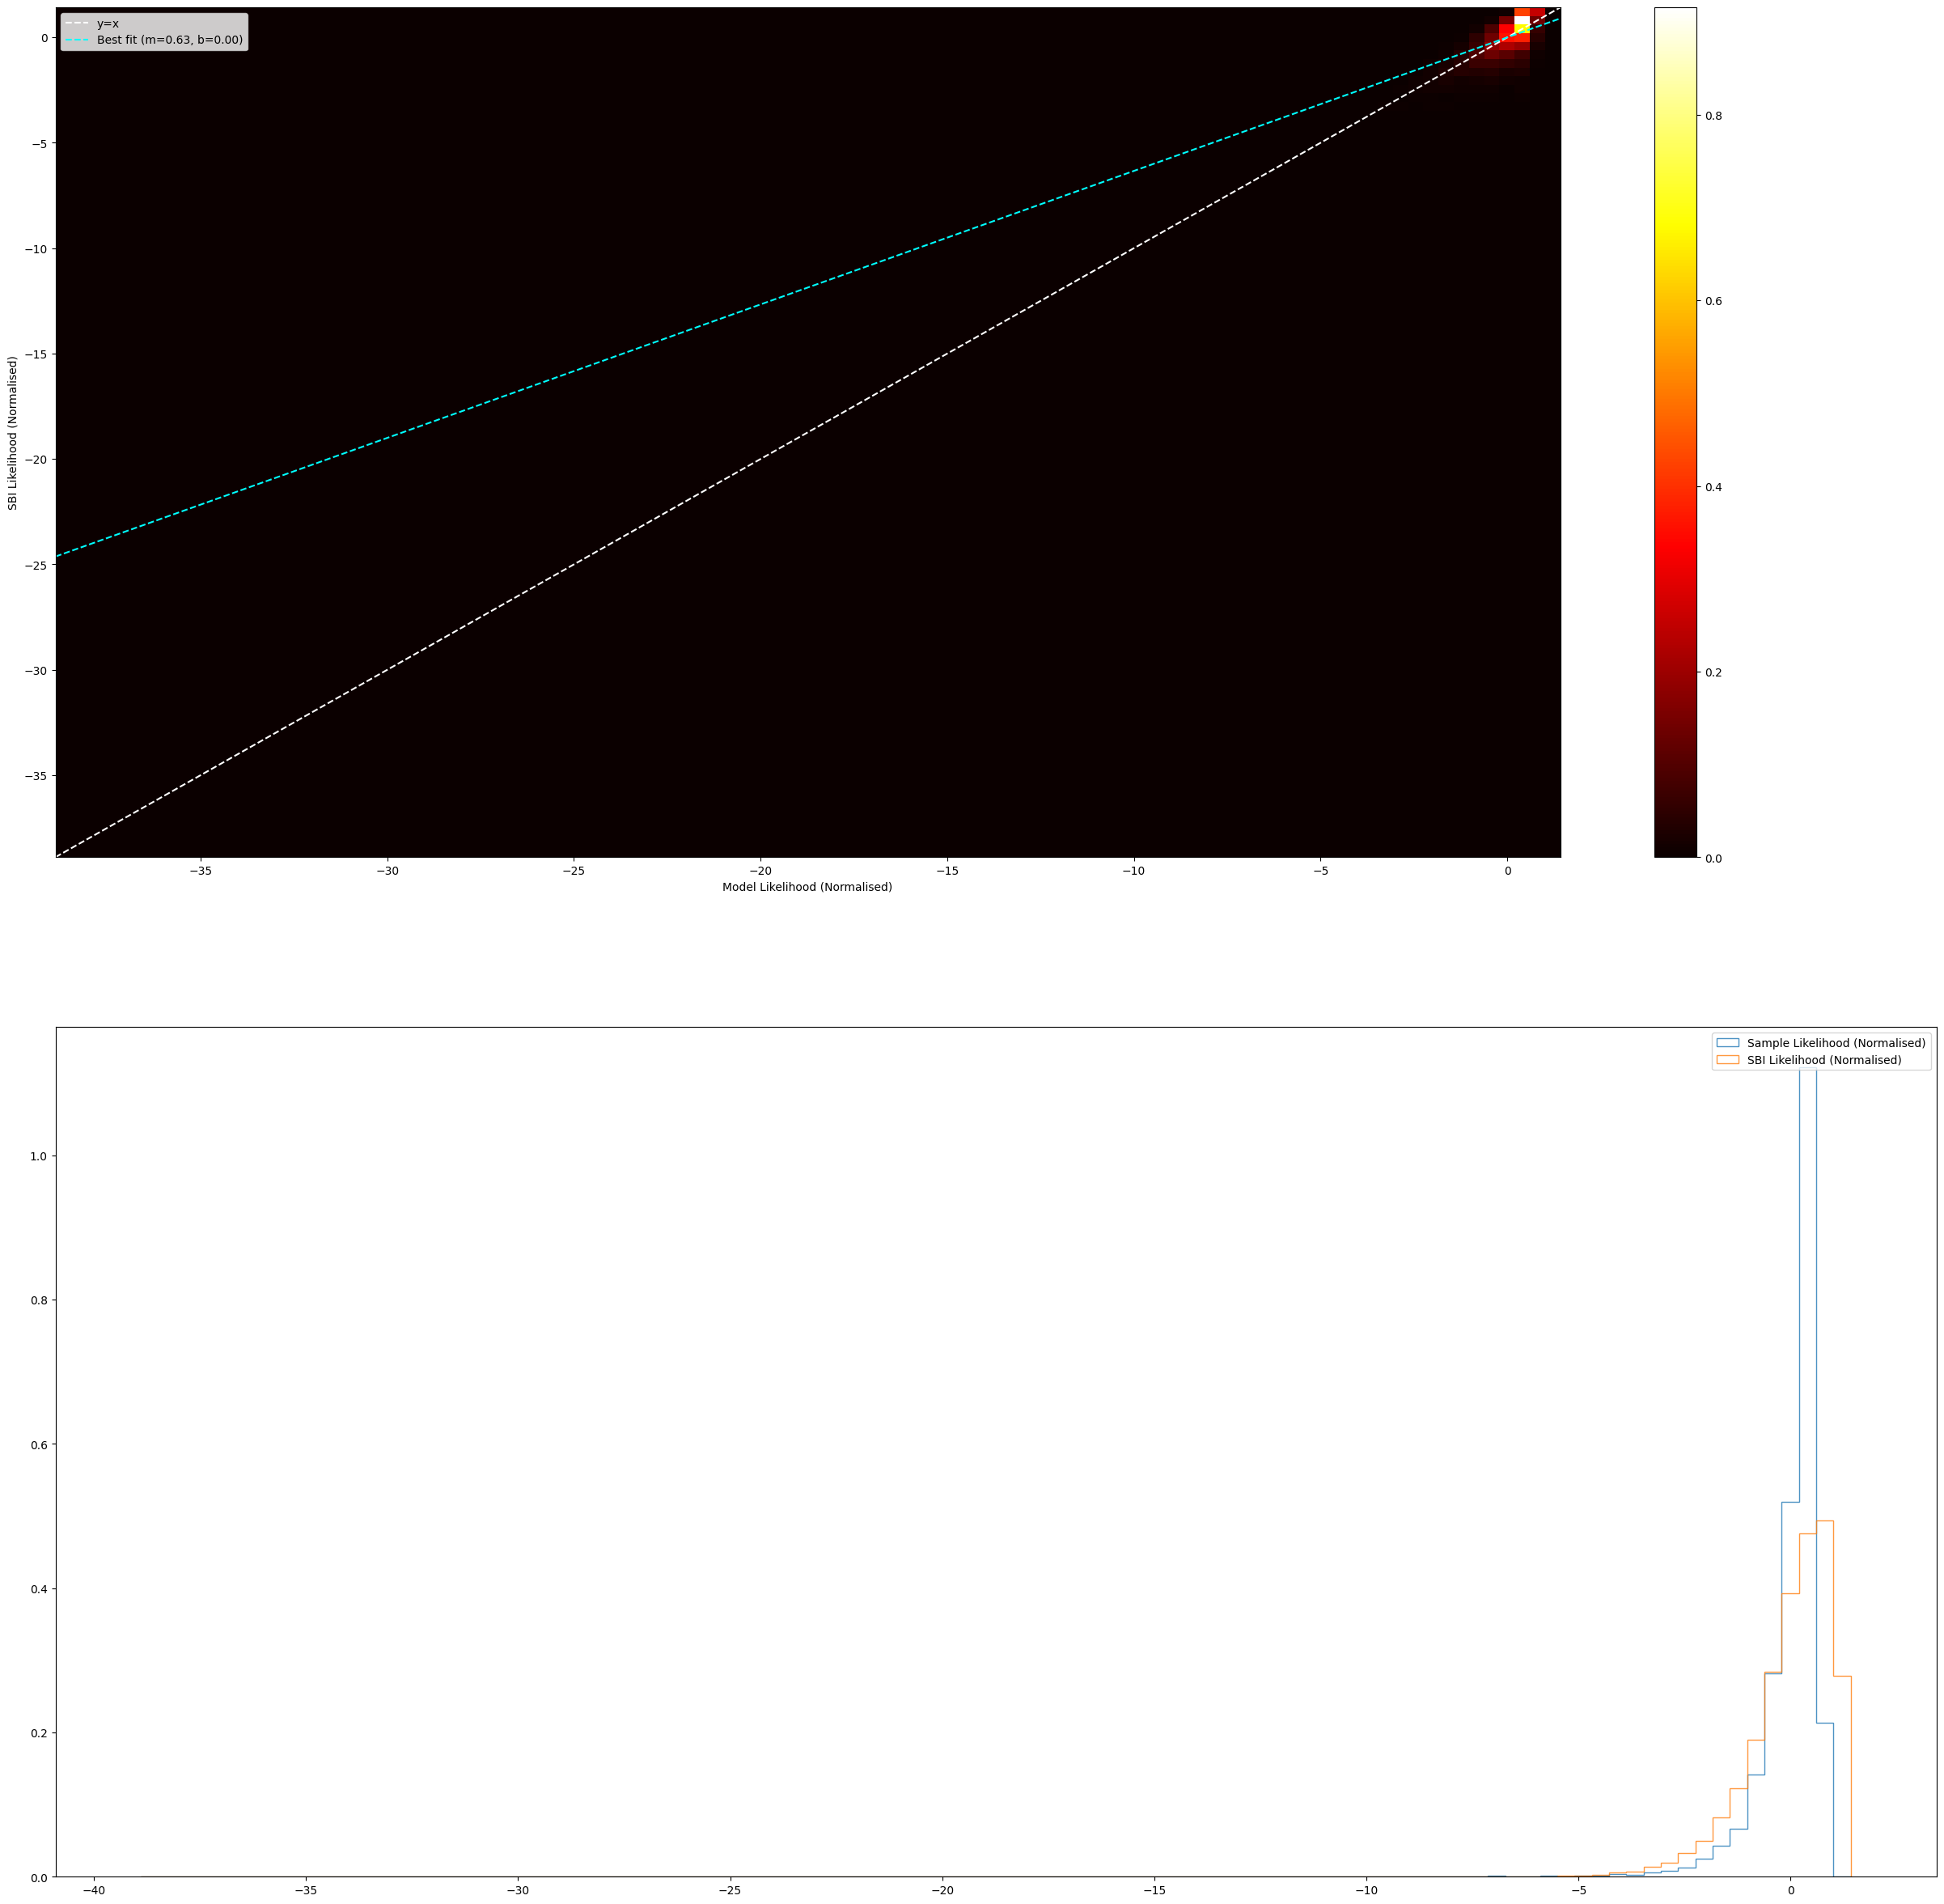

In [3]:
# Now we can compare the LLH
from mach3sbitools.diagnostics import compare_logl

# First step is to do a really rough pass
compare_logl(simulator, inference_handler, 10_000, n_bins=100)

  0%|          | 0/100000 [00:00<?, ?it/s]

Get LLH from simulator:   0%|          | 0/100000 [00:00<?, ?it/s]

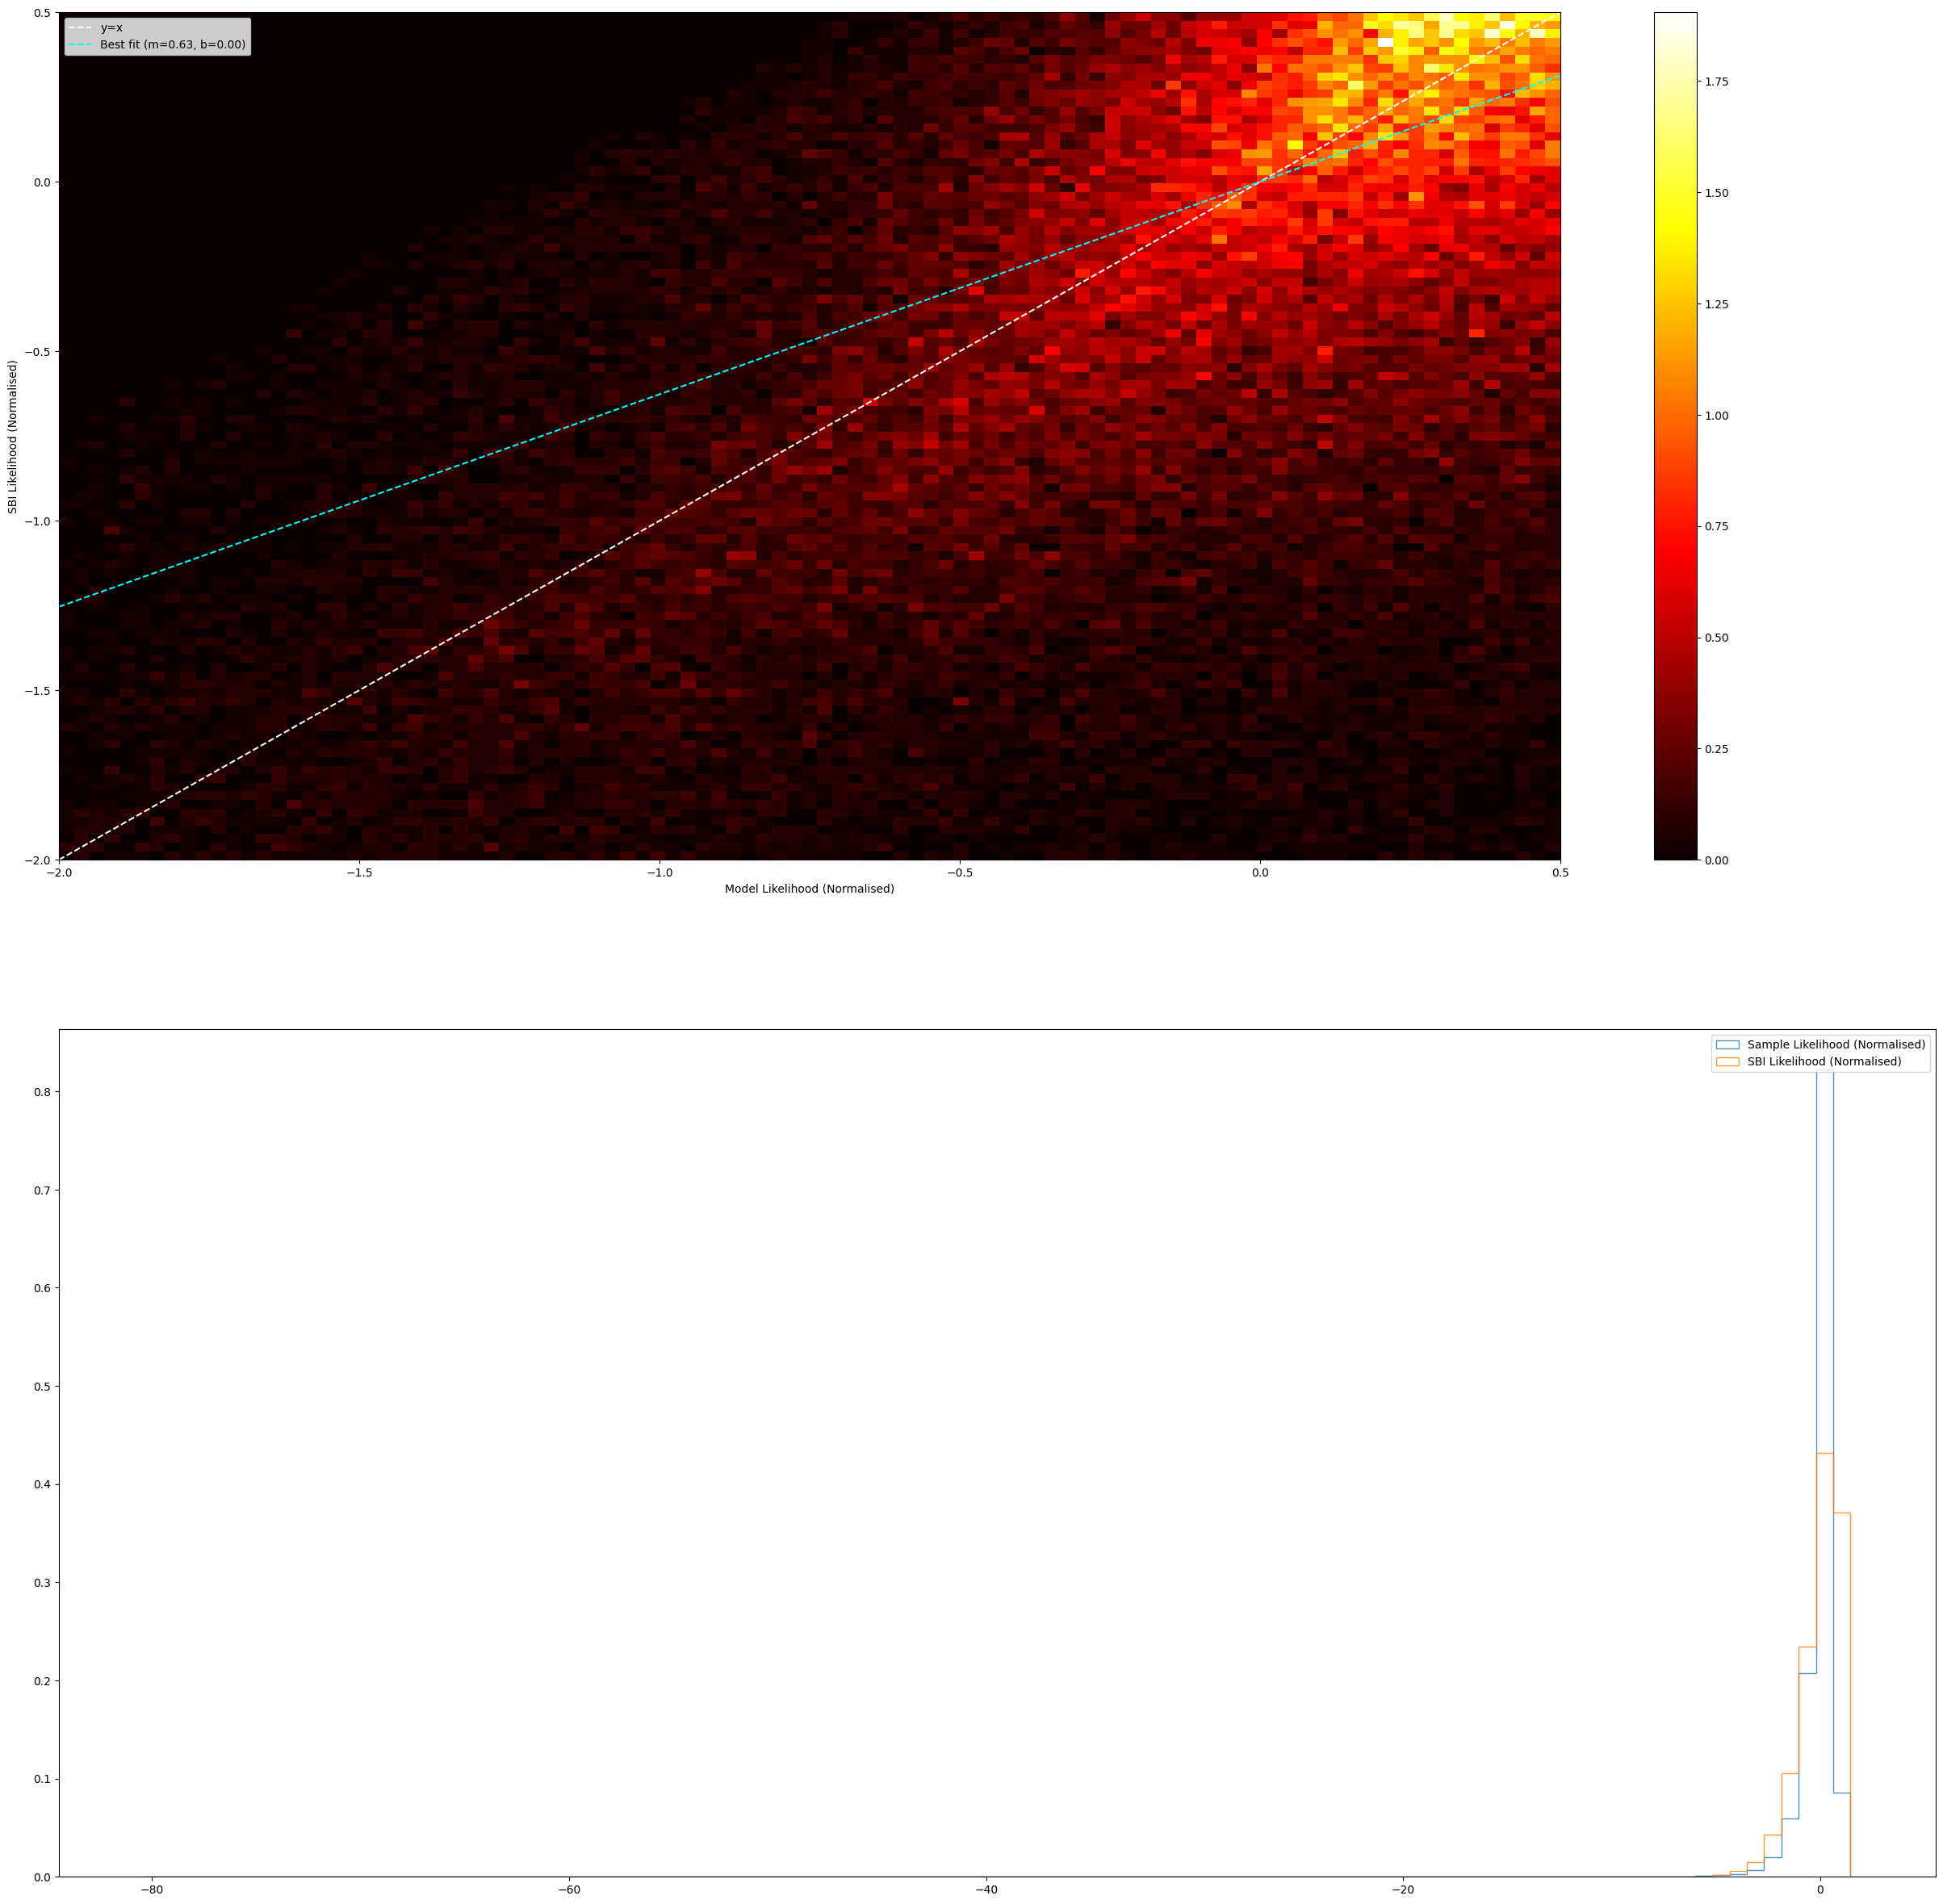

In [5]:
# Looks okay, let's zoom in on the 2D plot
compare_logl(simulator, inference_handler, 100_000, likelihood_range=[-2, 0.5], n_bins=100)